# Datos Climatológicos

## Consideraciones

Los datos disponibles a través del mapa de Información Estafística Climatológica del Servicio Meteorológico Nacional, contienen un formato basado en texto plano, que es necesario preprocesar. Utilizaremos la biblioteca `pandas`, para reordenar el contenido a un DataFrame.

Adicionalmente, existen datos faltantes en las mediciones por lo que aplicaremos los siguientes críterios para cada variable disponible.

| Variable                       | Tipo de dato        | Estrategia con nulos                                     | Justificación técnica                                                                                                                                                                        |
|--------------------------------|---------------------|----------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Lluvia acumulada / mensual     | Acumulada           | Trabajar con NaN (o imputar solo vía estaciones vecinas) | Una interpolación lineal inventa lluvia en días secos o subestima tormentas concentradas. Para balances anuales, si faltan meses, ese año se invalida.                                       |
| Lluvia máxima 24 h             | Extremo             | Trabajar con NaN estrictamente                           | Los eventos extremos no se pueden interpolar; rellenar con la media destruye el análisis de frecuencias (Gumbel, Pearson III).                                                               |
| Temperaturas (media, mín, máx) | Continua            | Imputar con perfil estacional (media mensual multianual) | Tienen fuerte autocorrelación y estacionalidad marcada. Un mes faltante puede aproximarse por el promedio histórico de ese mismo mes si la brecha es corta (1–2 meses).                      |
| Evaporación                    | Acumulada / balance | Trabajar con NaN                                         | Muy sensible a radiación y viento; si se requiere para balance de cuenca, es preferible estimarla por fórmulas indirectas (Thornthwaite, Hargreaves) a partir de temperatura que interpolar. |

## Estación Meteorológica Tláhuac

### Datos Mensuales

In [1]:
from pathlib import Path

# Ruta al archivo .txt
ruta_archivo = Path('../data/datos_climatologicos/tlahuac.txt')

# Lectura del archivo como string
try:
  with open(ruta_archivo, 'r', encoding='utf-8') as f:
    raw_text = f.read()
except UnicodeDecodeError:
  # Respaldo común para archivos de CONAGUA/SMN guardados en Windows ANSI
  with open(ruta_archivo, 'r', encoding='latin-1') as f:
    raw_text = f.read()

In [2]:
import io
import re
import pandas as pd

# Mapeo de meses en español a números enteros
MESES = {
    'ENE': 1,
    'FEB': 2,
    'MAR': 3,
    'ABR': 4,
    'MAY': 5,
    'JUN': 6,
    'JUL': 7,
    'AGO': 8,
    'SEP': 9,
    'OCT': 10,
    'NOV': 11,
    'DIC': 12,
}
COLS_MESES = list(MESES.keys())


def parse_clima_smn(raw_text: str) -> tuple[dict, pd.DataFrame]:
  # 1. Metadatos de cabecera
  metadata = {
      'estacion': re.search(r'ESTACIÓN\s*:\s*(\d+)', raw_text).group(1),
      'nombre': re.search(r'NOMBRE\s*:\s*([^\n\r]+)', raw_text).group(1).strip(),
      'latitud': float(
          re.search(r'LATITUD\s*:\s*([\d\.\-]+)', raw_text).group(1)
      ),
      'longitud': float(
          re.search(r'LONGITUD\s*:\s*([\d\.\-]+)', raw_text).group(1)
      ),
      'altitud': float(
          re.search(r'ALTITUD\s*:\s*([\d\.\-]+)', raw_text).group(1)
      ),
  }

  # 2. Segmentar bloques por nombres estándar de variables
  secciones = [
      'LLUVIA MÁXIMA 24 H.',
      'LLUVIA TOTAL MENSUAL',
      'EVAPORACIÓN MENSUAL',
      'TEMPERATURA MÁXIMA PROMEDIO',
      'TEMPERATURA MÁXIMA EXTREMA',
      'TEMPERATURA MÍNIMA PROMEDIO',
      'TEMPERATURA MÍNIMA EXTREMA',
      'TEMPERATURA MEDIA MENSUAL',
  ]

  dfs_long = []
  pattern = (
      r'(' + '|'.join([re.escape(s) for s in secciones]) + r')\s*\n(AÑO[^\n]+)'
  )

  # Dividir el texto en bloques tabulares
  splits = re.split(pattern, raw_text)

  for i in range(1, len(splits), 3):
    var_name = splits[i].strip()
    table_content = splits[i + 1] + splits[i + 2]

    # Cargar bloque ignorando espacios/tabs irregulares
    df_block = pd.read_csv(io.StringIO(table_content), sep='\t', engine='python')

    # Filtrar filas de resumen estadístico y años no numéricos
    df_block = df_block[
        pd.to_numeric(df_block['AÑO'], errors='coerce').notnull()
    ].copy()
    df_block['AÑO'] = df_block['AÑO'].astype(int)

    # Convertir a formato Long (Tidy)
    df_melt = df_block.melt(
        id_vars=['AÑO'],
        value_vars=[c for c in COLS_MESES if c in df_block.columns],
        var_name='MES',
        value_name=var_name,
    )

    # Forzar tipos numéricos flotantes (convierte celdas vacías en NaN)
    df_melt[var_name] = pd.to_numeric(df_melt[var_name], errors='coerce')
    dfs_long.append(df_melt.set_index(['AÑO', 'MES']))

  # 3. Consolidar todas las variables por índice temporal
  df_final = pd.concat(dfs_long, axis=1).reset_index()
  df_final['MES_NUM'] = df_final['MES'].map(MESES)
  df_final['FECHA'] = pd.to_datetime(
      df_final['AÑO'].astype(str)
      + '-'
      + df_final['MES_NUM'].astype(str).str.zfill(2)
      + '-01'
  )

  df_final = df_final.drop(columns=['AÑO', 'MES', 'MES_NUM']).set_index('FECHA')
  df_final = df_final.sort_index()

  return metadata, df_final

In [3]:
# Ejecución del parser
metadata, df_clima = parse_clima_smn(raw_text)

# Verificación rápida
print('Metadatos:', metadata)
display(df_clima.head())

# Estadísticos descriptivos estándar
display(df_clima.info())

# Porcentaje de datos faltantes por variable
nulos = (df_clima.isna().mean() * 100).round(2)
print("Porcentaje de nulos (%):\n", nulos)

Metadatos: {'estacion': '9051', 'nombre': 'TLAHUAC', 'latitud': 19.26277778, 'longitud': -99.00361111, 'altitud': 2240.0}


,LLUVIA MÁXIMA 24 H.,LLUVIA TOTAL MENSUAL,EVAPORACIÓN MENSUAL,TEMPERATURA MÁXIMA PROMEDIO,TEMPERATURA MÁXIMA EXTREMA,TEMPERATURA MÍNIMA PROMEDIO,TEMPERATURA MÍNIMA EXTREMA,TEMPERATURA MEDIA MENSUAL
FECHA,,,,,,,,
1961-01-01,6.0,6.61,NaN,NaN,NaN,NaN,NaN,NaN
1961-02-01,1.5,1.50,NaN,NaN,NaN,NaN,NaN,NaN
1961-03-01,8.5,8.62,NaN,NaN,NaN,NaN,NaN,NaN
1961-04-01,4.5,6.40,NaN,NaN,NaN,NaN,NaN,NaN
1961-05-01,5.4,6.70,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
DatetimeIndex: 708 entries, 1961-01-01 to 2026-12-01
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   LLUVIA MÁXIMA 24 H.          675 non-null    float64
 1   LLUVIA TOTAL MENSUAL         675 non-null    float64
 2   EVAPORACIÓN MENSUAL          456 non-null    float64
 3   TEMPERATURA MÁXIMA PROMEDIO  614 non-null    float64
 4   TEMPERATURA MÁXIMA EXTREMA   614 non-null    float64
 5   TEMPERATURA MÍNIMA PROMEDIO  614 non-null    float64
 6   TEMPERATURA MÍNIMA EXTREMA   614 non-null    float64
 7   TEMPERATURA MEDIA MENSUAL    614 non-null    float64
dtypes: float64(8)
memory usage: 49.8 KB


None

Porcentaje de nulos (%):
 LLUVIA MÁXIMA 24 H.             4.66
LLUVIA TOTAL MENSUAL            4.66
EVAPORACIÓN MENSUAL            35.59
TEMPERATURA MÁXIMA PROMEDIO    13.28
TEMPERATURA MÁXIMA EXTREMA     13.28
TEMPERATURA MÍNIMA PROMEDIO    13.28
TEMPERATURA MÍNIMA EXTREMA     13.28
TEMPERATURA MEDIA MENSUAL      13.28
dtype: float64


In [4]:
# Filtrar desde el 1 de enero de 1994 hasta la fecha más reciente disponible
df_1994 = df_clima.loc['1994':].copy()

# Verificar rango de fechas resultante y dimensiones
print(f'Rango: {df_1994.index.min().date()} a {df_1994.index.max().date()}')
print(f'Dimensiones: {df_1994.shape}')
display(df_1994.head())

Rango: 1996-01-01 a 2026-12-01
Dimensiones: (372, 8)


,LLUVIA MÁXIMA 24 H.,LLUVIA TOTAL MENSUAL,EVAPORACIÓN MENSUAL,TEMPERATURA MÁXIMA PROMEDIO,TEMPERATURA MÁXIMA EXTREMA,TEMPERATURA MÍNIMA PROMEDIO,TEMPERATURA MÍNIMA EXTREMA,TEMPERATURA MEDIA MENSUAL
FECHA,,,,,,,,
1996-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1996-02-01,0.0,0.0,95.37,26.2,30.0,9.4,6.0,17.8
1996-03-01,0.0,0.0,141.26,28.5,30.0,11.0,8.0,19.8
1996-04-01,16.0,26.0,121.31,28.4,29.5,11.6,11.0,20.0
1996-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Dataframe con datos vacios

# Generar índice mensual continuo desde 1994
idx_continuo = pd.date_range(
    start='1994-01-01', end=df_clima.index.max(), freq='MS'
)

# Reindexar el DataFrame base recortado
df_raw = df_clima.reindex(idx_continuo)
df_raw.index.name = 'FECHA'

print('Dimensiones df_raw:', df_raw.shape)
print('Conteo de nulos por columna:\n', df_raw.isna().sum())

Dimensiones df_raw: (396, 8)
Conteo de nulos por columna:
 LLUVIA MÁXIMA 24 H.            54
LLUVIA TOTAL MENSUAL           54
EVAPORACIÓN MENSUAL            79
TEMPERATURA MÁXIMA PROMEDIO    65
TEMPERATURA MÁXIMA EXTREMA     65
TEMPERATURA MÍNIMA PROMEDIO    65
TEMPERATURA MÍNIMA EXTREMA     65
TEMPERATURA MEDIA MENSUAL      65
dtype: int64


In [6]:
# Dataframe con datos calculados
df_work = df_raw.copy()

cols_temp = [
    'TEMPERATURA MEDIA MENSUAL',
    'TEMPERATURA MÁXIMA PROMEDIO',
    'TEMPERATURA MÍNIMA PROMEDIO',
]

for col in cols_temp:
  # Media climatológica mensual histórica (1 a 12)
  media_mes = df_work.groupby(df_work.index.month)[col].transform('mean')

  # Identificar rachas consecutivas de NaN
  es_nulo = df_work[col].isna()
  grupo_rachas = (~es_nulo).cumsum()

  # Se aplica transform('size') directo sobre la Serie 'es_nulo'
  rachas_tamano = (
      es_nulo.groupby(grupo_rachas).transform('size').where(es_nulo, 0)
  )

  # Imputar únicamente donde la racha de NaN sea <= 2 meses
  df_work[col] = df_work[col].fillna(media_mes.where(rachas_tamano <= 2))

print('Nulos restantes en df_work:\n', df_work.isna().sum())

Nulos restantes en df_work:
 LLUVIA MÁXIMA 24 H.            54
LLUVIA TOTAL MENSUAL           54
EVAPORACIÓN MENSUAL            79
TEMPERATURA MÁXIMA PROMEDIO    62
TEMPERATURA MÁXIMA EXTREMA     65
TEMPERATURA MÍNIMA PROMEDIO    62
TEMPERATURA MÍNIMA EXTREMA     65
TEMPERATURA MEDIA MENSUAL      62
dtype: int64


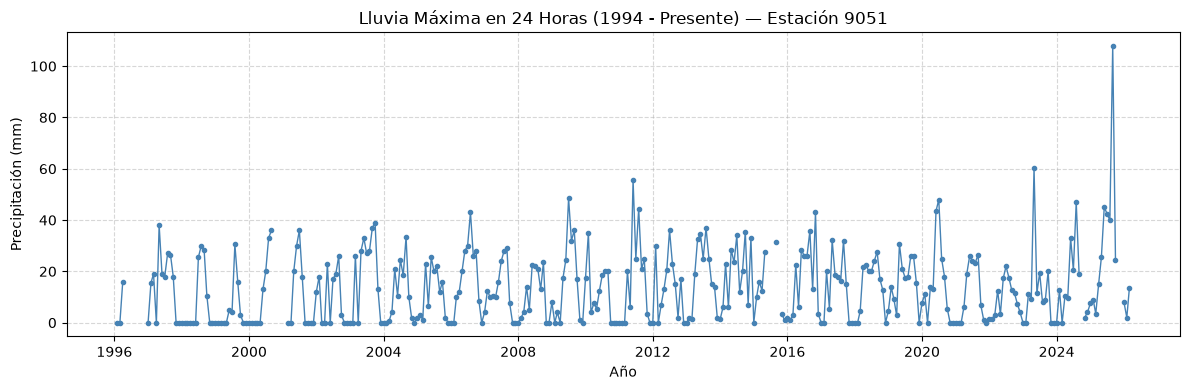

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['LLUVIA MÁXIMA 24 H.'],
    color='steelblue',
    marker='o',
    markersize=3,
    linewidth=1,
)
plt.title(f'Lluvia Máxima en 24 Horas (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Precipitación (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

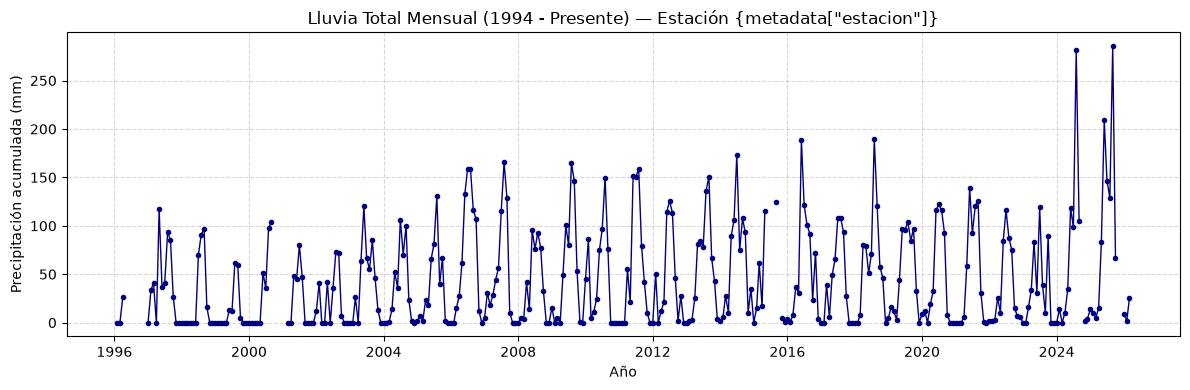

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['LLUVIA TOTAL MENSUAL'],
    color='navy',
    marker='.',
    linewidth=1,
)
plt.title('Lluvia Total Mensual (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Precipitación acumulada (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

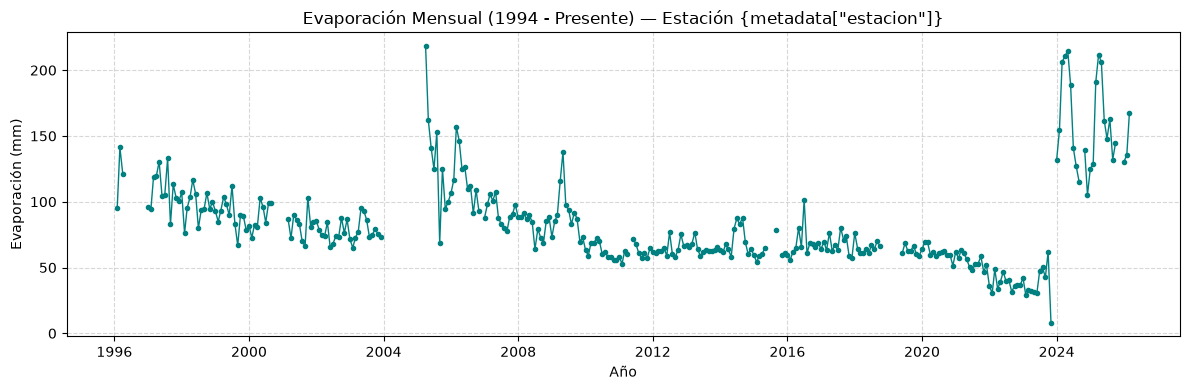

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['EVAPORACIÓN MENSUAL'],
    color='teal',
    marker='.',
    linewidth=1,
)
plt.title('Evaporación Mensual (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Evaporación (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

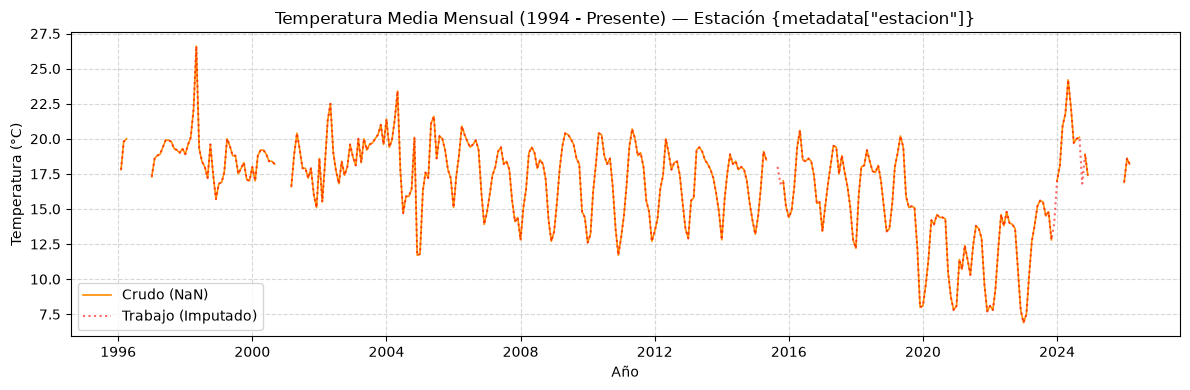

In [10]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['TEMPERATURA MEDIA MENSUAL'],
    color='darkorange',
    linewidth=1.2,
    label='Crudo (NaN)',
)
plt.plot(
    df_work.index,
    df_work['TEMPERATURA MEDIA MENSUAL'],
    color='red',
    linestyle=':',
    alpha=0.6,
    label='Trabajo (Imputado)',
)
plt.title('Temperatura Media Mensual (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

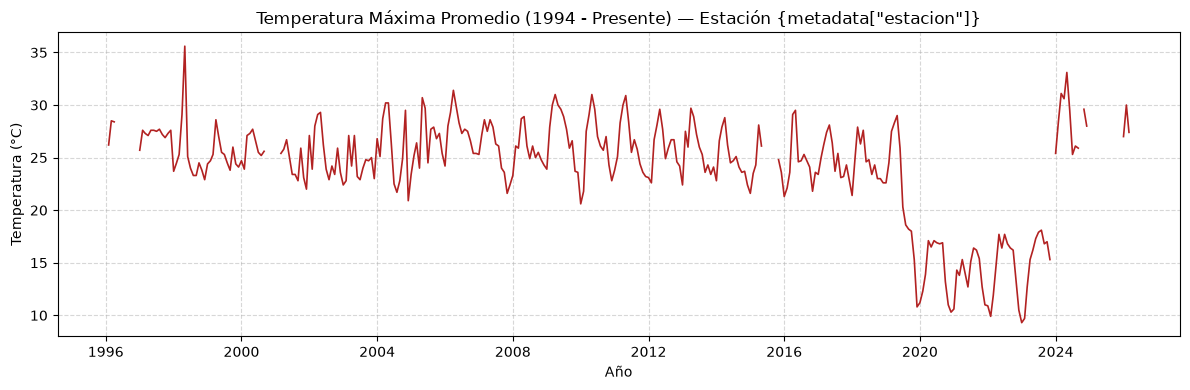

In [11]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['TEMPERATURA MÁXIMA PROMEDIO'],
    color='firebrick',
    linewidth=1.2,
)
plt.title('Temperatura Máxima Promedio (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Temperatura (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

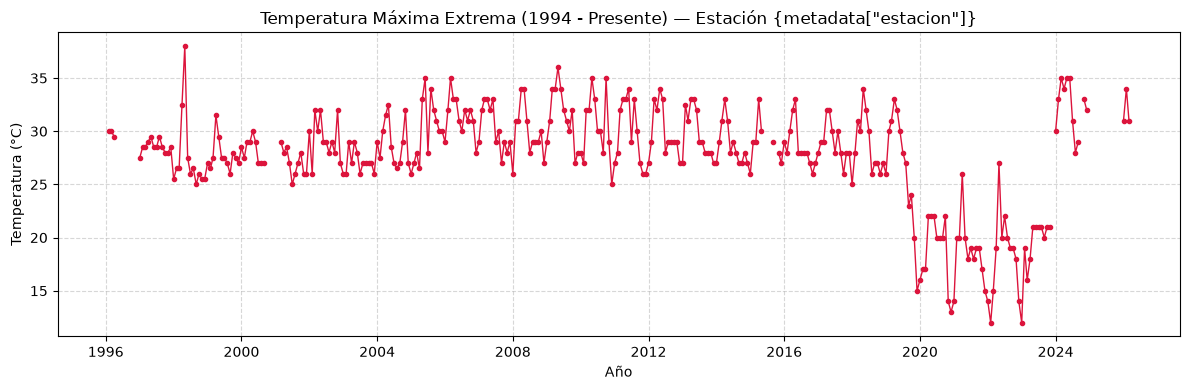

In [12]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['TEMPERATURA MÁXIMA EXTREMA'],
    color='crimson',
    marker='o',
    markersize=3,
    linewidth=1,
)
plt.title('Temperatura Máxima Extrema (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Temperatura (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

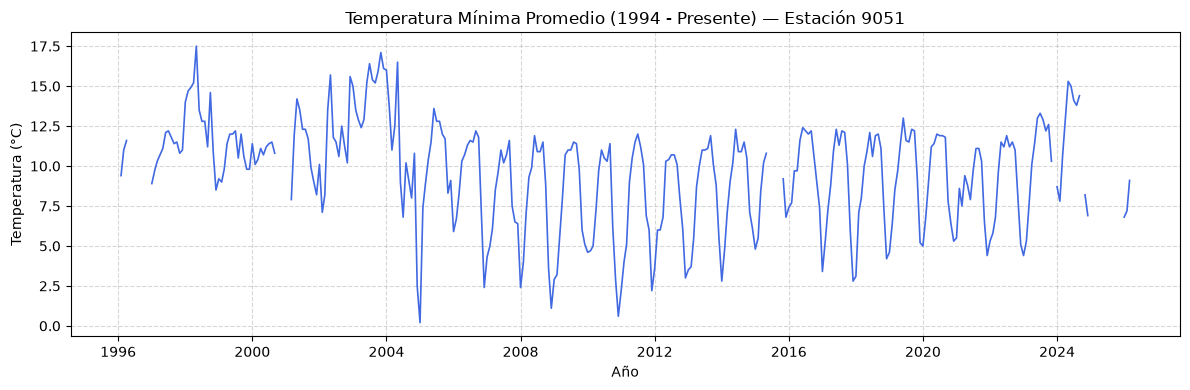

In [13]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['TEMPERATURA MÍNIMA PROMEDIO'],
    color='royalblue',
    linewidth=1.2,
)
plt.title(f'Temperatura Mínima Promedio (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Temperatura (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

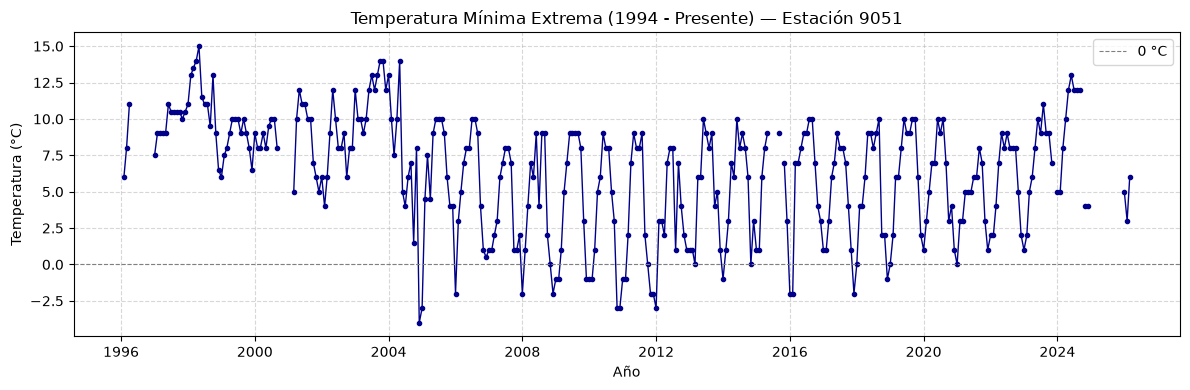

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['TEMPERATURA MÍNIMA EXTREMA'],
    color='darkblue',
    marker='o',
    markersize=3,
    linewidth=1,
)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, label='0 °C')
plt.title(f'Temperatura Mínima Extrema (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

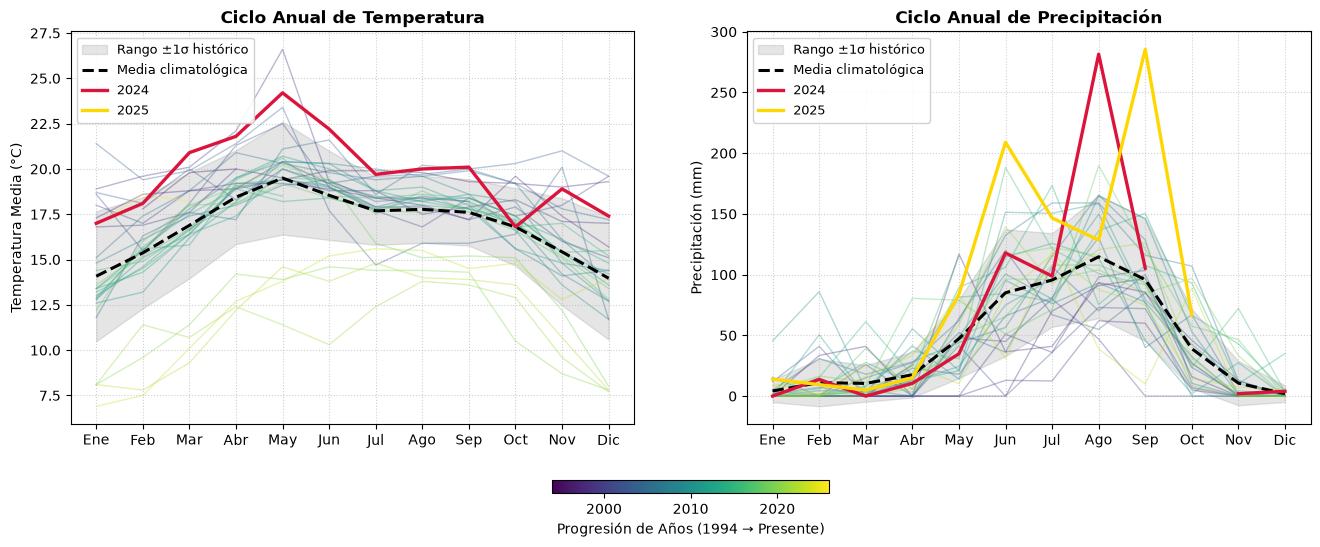

In [15]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Preparar tabla pivote (Meses en filas 1-12, Años en columnas)
df_plot = df_work.copy()
df_plot['AÑO'] = df_plot.index.year
df_plot['MES'] = df_plot.index.month

meses_labels = [
    'Ene',
    'Feb',
    'Mar',
    'Abr',
    'May',
    'Jun',
    'Jul',
    'Ago',
    'Sep',
    'Oct',
    'Nov',
    'Dic',
]
x_axis = np.arange(1, 13)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

variables = [
    (
        'TEMPERATURA MEDIA MENSUAL',
        'Temperatura Media (°C)',
        axes[0],
        'Ciclo Anual de Temperatura',
    ),
    (
        'LLUVIA TOTAL MENSUAL',
        'Precipitación (mm)',
        axes[1],
        'Ciclo Anual de Precipitación',
    ),
]

anios = sorted(df_plot['AÑO'].unique())
norm = plt.Normalize(vmin=min(anios), vmax=max(anios))
cmap = cm.viridis

for col_name, y_label, ax, title in variables:
  pivot = df_plot.pivot(index='MES', columns='AÑO', values=col_name).reindex(
      x_axis
  )

  # 1. Banda climatológica: Media +/- 1 Desviación Estándar
  media_clim = pivot.mean(axis=1)
  std_clim = pivot.std(axis=1)
  ax.fill_between(
      x_axis,
      media_clim - std_clim,
      media_clim + std_clim,
      color='gray',
      alpha=0.2,
      label='Rango ±1σ histórico',
  )
  ax.plot(
      x_axis,
      media_clim,
      color='black',
      linewidth=2.2,
      linestyle='--',
      label='Media climatológica',
      zorder=4,
  )

  # 2. Curvas de cada año con gradiente de color
  for anio in anios:
    if anio in [2024, 2025]:
      continue  # Se grafican al final para destacarlos
    ax.plot(
        x_axis,
        pivot[anio],
        color=cmap(norm(anio)),
        alpha=0.35,
        linewidth=1.0,
        zorder=2,
    )

  # 3. Resaltar años recientes anómalos
  if 2024 in pivot.columns:
    ax.plot(
        x_axis,
        pivot[2024],
        color='crimson',
        linewidth=2.4,
        label='2024',
        zorder=5,
    )
  if 2025 in pivot.columns:
    ax.plot(
        x_axis,
        pivot[2025],
        color='gold',
        linewidth=2.4,
        label='2025',
        zorder=5,
    )

  ax.set_title(title, fontsize=12, fontweight='bold')
  ax.set_ylabel(y_label)
  ax.set_xticks(x_axis)
  ax.set_xticklabels(meses_labels)
  ax.grid(True, linestyle=':', alpha=0.6)
  ax.legend(loc='upper left', framealpha=0.9, fontsize=9)

# Barra de color indicando la progresión de los años
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes, orientation='horizontal', fraction=0.03, pad=0.12
)
cbar.set_label('Progresión de Años (1994 → Presente)', fontsize=10)

plt.show()

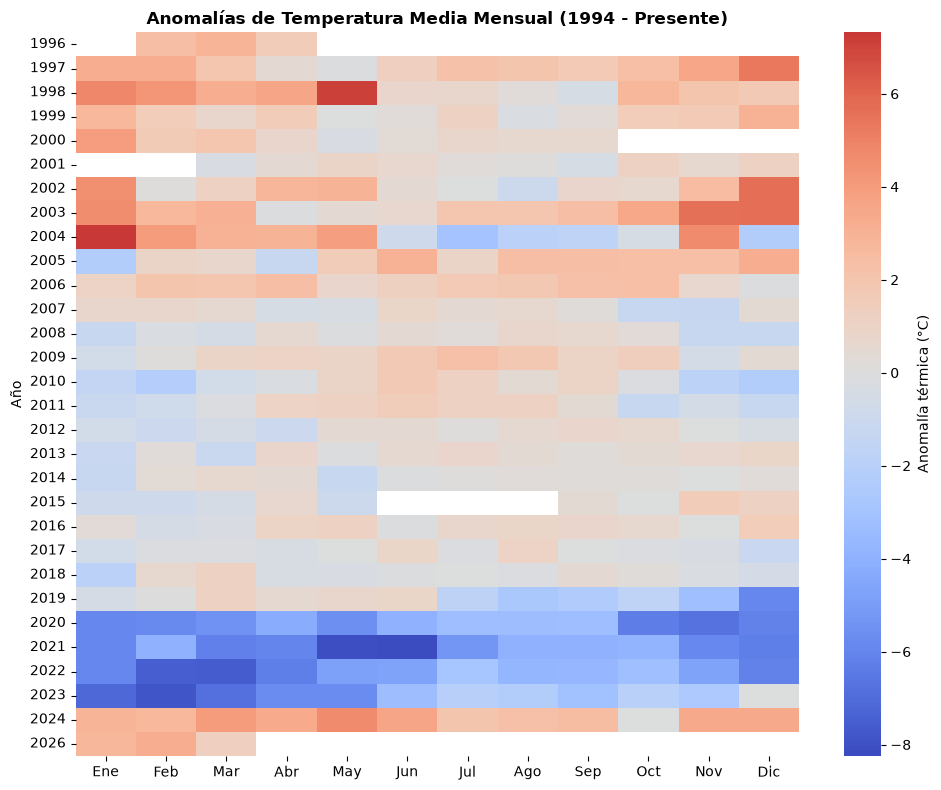

In [16]:
import seaborn as sns

plt.figure(figsize=(10, 8))
piv_temp = df_work.pivot_table(
    index=df_work.index.year,
    columns=df_work.index.month,
    values='TEMPERATURA MEDIA MENSUAL',
)
piv_temp.columns = meses_labels

# Restar la media histórica de cada mes para ver anomalías
anomalias_temp = piv_temp - piv_temp.mean(axis=0)

sns.heatmap(
    anomalias_temp,
    cmap='coolwarm',
    center=0,
    cbar_kws={'label': 'Anomalía térmica (°C)'},
)
plt.title(
    'Anomalías de Temperatura Media Mensual (1994 - Presente)',
    fontweight='bold',
)
plt.ylabel('Año')
plt.tight_layout()
plt.show()

## Estación Meteorológica Milpa Alta

### Datos Mensuales

In [17]:
from pathlib import Path

# Ruta al archivo .txt
ruta_archivo = Path('../data/datos_climatologicos/milpa_alta.txt')

# Lectura del archivo como string
try:
  with open(ruta_archivo, 'r', encoding='utf-8') as f:
    raw_text = f.read()
except UnicodeDecodeError:
  # Respaldo común para archivos de CONAGUA/SMN guardados en Windows ANSI
  with open(ruta_archivo, 'r', encoding='latin-1') as f:
    raw_text = f.read()

In [18]:
import io
import re
import pandas as pd

# Mapeo de meses en español a números enteros
MESES = {
    'ENE': 1,
    'FEB': 2,
    'MAR': 3,
    'ABR': 4,
    'MAY': 5,
    'JUN': 6,
    'JUL': 7,
    'AGO': 8,
    'SEP': 9,
    'OCT': 10,
    'NOV': 11,
    'DIC': 12,
}
COLS_MESES = list(MESES.keys())


def parse_clima_smn(raw_text: str) -> tuple[dict, pd.DataFrame]:
  # 1. Metadatos de cabecera
  metadata = {
      'estacion': re.search(r'ESTACIÓN\s*:\s*(\d+)', raw_text).group(1),
      'nombre': re.search(r'NOMBRE\s*:\s*([^\n\r]+)', raw_text).group(1).strip(),
      'latitud': float(
          re.search(r'LATITUD\s*:\s*([\d\.\-]+)', raw_text).group(1)
      ),
      'longitud': float(
          re.search(r'LONGITUD\s*:\s*([\d\.\-]+)', raw_text).group(1)
      ),
      'altitud': float(
          re.search(r'ALTITUD\s*:\s*([\d\.\-]+)', raw_text).group(1)
      ),
  }

  # 2. Segmentar bloques por nombres estándar de variables
  secciones = [
      'LLUVIA MÁXIMA 24 H.',
      'LLUVIA TOTAL MENSUAL',
      'EVAPORACIÓN MENSUAL',
      'TEMPERATURA MÁXIMA PROMEDIO',
      'TEMPERATURA MÁXIMA EXTREMA',
      'TEMPERATURA MÍNIMA PROMEDIO',
      'TEMPERATURA MÍNIMA EXTREMA',
      'TEMPERATURA MEDIA MENSUAL',
  ]

  dfs_long = []
  pattern = (
      r'(' + '|'.join([re.escape(s) for s in secciones]) + r')\s*\n(AÑO[^\n]+)'
  )

  # Dividir el texto en bloques tabulares
  splits = re.split(pattern, raw_text)

  for i in range(1, len(splits), 3):
    var_name = splits[i].strip()
    table_content = splits[i + 1] + splits[i + 2]

    # Cargar bloque ignorando espacios/tabs irregulares
    df_block = pd.read_csv(io.StringIO(table_content), sep='\t', engine='python')

    # Filtrar filas de resumen estadístico y años no numéricos
    df_block = df_block[
        pd.to_numeric(df_block['AÑO'], errors='coerce').notnull()
    ].copy()
    df_block['AÑO'] = df_block['AÑO'].astype(int)

    # Convertir a formato Long (Tidy)
    df_melt = df_block.melt(
        id_vars=['AÑO'],
        value_vars=[c for c in COLS_MESES if c in df_block.columns],
        var_name='MES',
        value_name=var_name,
    )

    # Forzar tipos numéricos flotantes (convierte celdas vacías en NaN)
    df_melt[var_name] = pd.to_numeric(df_melt[var_name], errors='coerce')
    dfs_long.append(df_melt.set_index(['AÑO', 'MES']))

  # 3. Consolidar todas las variables por índice temporal
  df_final = pd.concat(dfs_long, axis=1).reset_index()
  df_final['MES_NUM'] = df_final['MES'].map(MESES)
  df_final['FECHA'] = pd.to_datetime(
      df_final['AÑO'].astype(str)
      + '-'
      + df_final['MES_NUM'].astype(str).str.zfill(2)
      + '-01'
  )

  df_final = df_final.drop(columns=['AÑO', 'MES', 'MES_NUM']).set_index('FECHA')
  df_final = df_final.sort_index()

  return metadata, df_final

In [19]:
# Ejecución del parser
metadata, df_clima = parse_clima_smn(raw_text)

# Verificación rápida
print('Metadatos:', metadata)
display(df_clima.head())

# Estadísticos descriptivos estándar
display(df_clima.info())

# Porcentaje de datos faltantes por variable
nulos = (df_clima.isna().mean() * 100).round(2)
print("Porcentaje de nulos (%):\n", nulos)

Metadatos: {'estacion': '9032', 'nombre': 'MILPA ALTA', 'latitud': 19.19055556, 'longitud': -99.02194444, 'altitud': 2420.0}


,LLUVIA MÁXIMA 24 H.,LLUVIA TOTAL MENSUAL,EVAPORACIÓN MENSUAL,TEMPERATURA MÁXIMA PROMEDIO,TEMPERATURA MÁXIMA EXTREMA,TEMPERATURA MÍNIMA PROMEDIO,TEMPERATURA MÍNIMA EXTREMA,TEMPERATURA MEDIA MENSUAL
FECHA,,,,,,,,
1929-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-03-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1929-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.DataFrame'>
DatetimeIndex: 972 entries, 1929-01-01 to 2026-12-01
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   LLUVIA MÁXIMA 24 H.          892 non-null    float64
 1   LLUVIA TOTAL MENSUAL         892 non-null    float64
 2   EVAPORACIÓN MENSUAL          488 non-null    float64
 3   TEMPERATURA MÁXIMA PROMEDIO  798 non-null    float64
 4   TEMPERATURA MÁXIMA EXTREMA   798 non-null    float64
 5   TEMPERATURA MÍNIMA PROMEDIO  798 non-null    float64
 6   TEMPERATURA MÍNIMA EXTREMA   798 non-null    float64
 7   TEMPERATURA MEDIA MENSUAL    798 non-null    float64
dtypes: float64(8)
memory usage: 68.3 KB


None

Porcentaje de nulos (%):
 LLUVIA MÁXIMA 24 H.             8.23
LLUVIA TOTAL MENSUAL            8.23
EVAPORACIÓN MENSUAL            49.79
TEMPERATURA MÁXIMA PROMEDIO    17.90
TEMPERATURA MÁXIMA EXTREMA     17.90
TEMPERATURA MÍNIMA PROMEDIO    17.90
TEMPERATURA MÍNIMA EXTREMA     17.90
TEMPERATURA MEDIA MENSUAL      17.90
dtype: float64


In [20]:
# Filtrar desde el 1 de enero de 1994 hasta la fecha más reciente disponible
df_1994 = df_clima.loc['1994':].copy()

# Verificar rango de fechas resultante y dimensiones
print(f'Rango: {df_1994.index.min().date()} a {df_1994.index.max().date()}')
print(f'Dimensiones: {df_1994.shape}')
display(df_1994.head())

Rango: 1994-01-01 a 2026-12-01
Dimensiones: (396, 8)


,LLUVIA MÁXIMA 24 H.,LLUVIA TOTAL MENSUAL,EVAPORACIÓN MENSUAL,TEMPERATURA MÁXIMA PROMEDIO,TEMPERATURA MÁXIMA EXTREMA,TEMPERATURA MÍNIMA PROMEDIO,TEMPERATURA MÍNIMA EXTREMA,TEMPERATURA MEDIA MENSUAL
FECHA,,,,,,,,
1994-01-01,1.50,1.70,111.40,19.2,23.5,3.9,-1.0,11.5
1994-02-01,0.01,0.01,145.08,21.5,24.0,5.7,3.5,13.6
1994-03-01,0.01,0.02,229.52,24.1,27.5,7.3,4.0,15.7
1994-04-01,16.80,30.32,195.80,23.1,27.5,8.1,5.5,15.6
1994-05-01,43.50,119.63,182.04,24.0,27.5,9.4,6.0,16.7


| Variable                       | Tipo de dato        | Estrategia con nulos                                     | Justificación técnica                                                                                                                                                                        |
|--------------------------------|---------------------|----------------------------------------------------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Lluvia acumulada / mensual     | Acumulada           | Trabajar con NaN (o imputar solo vía estaciones vecinas) | Una interpolación lineal inventa lluvia en días secos o subestima tormentas concentradas. Para balances anuales, si faltan meses, ese año se invalida.                                       |
| Lluvia máxima 24 h             | Extremo             | Trabajar con NaN estrictamente                           | Los eventos extremos no se pueden interpolar; rellenar con la media destruye el análisis de frecuencias (Gumbel, Pearson III).                                                               |
| Temperaturas (media, mín, máx) | Continua            | Imputar con perfil estacional (media mensual multianual) | Tienen fuerte autocorrelación y estacionalidad marcada. Un mes faltante puede aproximarse por el promedio histórico de ese mismo mes si la brecha es corta (1–2 meses).                      |
| Evaporación                    | Acumulada / balance | Trabajar con NaN                                         | Muy sensible a radiación y viento; si se requiere para balance de cuenca, es preferible estimarla por fórmulas indirectas (Thornthwaite, Hargreaves) a partir de temperatura que interpolar. |

In [21]:
# Dataframe con datos vacios

# Generar índice mensual continuo desde 1994
idx_continuo = pd.date_range(
    start='1994-01-01', end=df_clima.index.max(), freq='MS'
)

# Reindexar el DataFrame base recortado
df_raw = df_clima.reindex(idx_continuo)
df_raw.index.name = 'FECHA'

print('Dimensiones df_raw:', df_raw.shape)
print('Conteo de nulos por columna:\n', df_raw.isna().sum())

Dimensiones df_raw: (396, 8)
Conteo de nulos por columna:
 LLUVIA MÁXIMA 24 H.             35
LLUVIA TOTAL MENSUAL            35
EVAPORACIÓN MENSUAL            264
TEMPERATURA MÁXIMA PROMEDIO     30
TEMPERATURA MÁXIMA EXTREMA      30
TEMPERATURA MÍNIMA PROMEDIO     30
TEMPERATURA MÍNIMA EXTREMA      30
TEMPERATURA MEDIA MENSUAL       30
dtype: int64


In [22]:
# Dataframe con datos calculados
df_work = df_raw.copy()

cols_temp = [
    'TEMPERATURA MEDIA MENSUAL',
    'TEMPERATURA MÁXIMA PROMEDIO',
    'TEMPERATURA MÍNIMA PROMEDIO',
]

for col in cols_temp:
  # Media climatológica mensual histórica (1 a 12)
  media_mes = df_work.groupby(df_work.index.month)[col].transform('mean')

  # Identificar rachas consecutivas de NaN
  es_nulo = df_work[col].isna()
  grupo_rachas = (~es_nulo).cumsum()

  # Se aplica transform('size') directo sobre la Serie 'es_nulo'
  rachas_tamano = (
      es_nulo.groupby(grupo_rachas).transform('size').where(es_nulo, 0)
  )

  # Imputar únicamente donde la racha de NaN sea <= 2 meses
  df_work[col] = df_work[col].fillna(media_mes.where(rachas_tamano <= 2))

print('Nulos restantes en df_work:\n', df_work.isna().sum())

Nulos restantes en df_work:
 LLUVIA MÁXIMA 24 H.             35
LLUVIA TOTAL MENSUAL            35
EVAPORACIÓN MENSUAL            264
TEMPERATURA MÁXIMA PROMEDIO     26
TEMPERATURA MÁXIMA EXTREMA      30
TEMPERATURA MÍNIMA PROMEDIO     26
TEMPERATURA MÍNIMA EXTREMA      30
TEMPERATURA MEDIA MENSUAL       26
dtype: int64


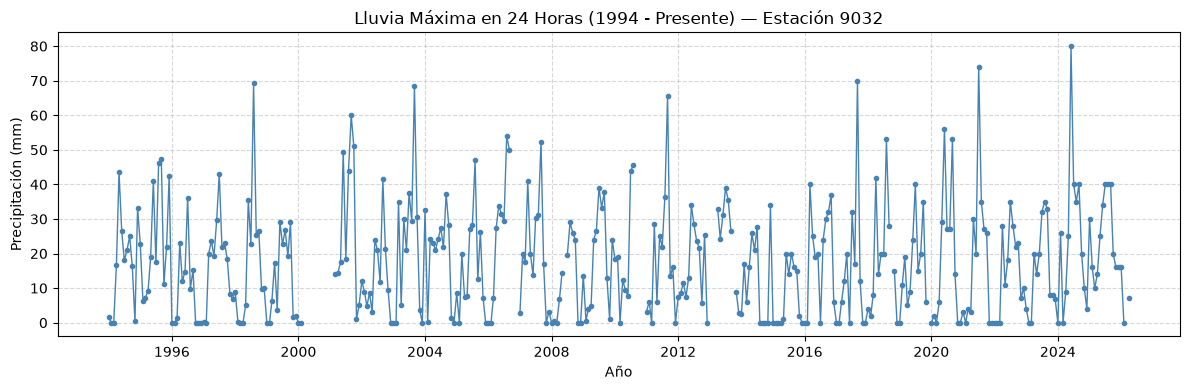

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['LLUVIA MÁXIMA 24 H.'],
    color='steelblue',
    marker='o',
    markersize=3,
    linewidth=1,
)
plt.title(f'Lluvia Máxima en 24 Horas (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Precipitación (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

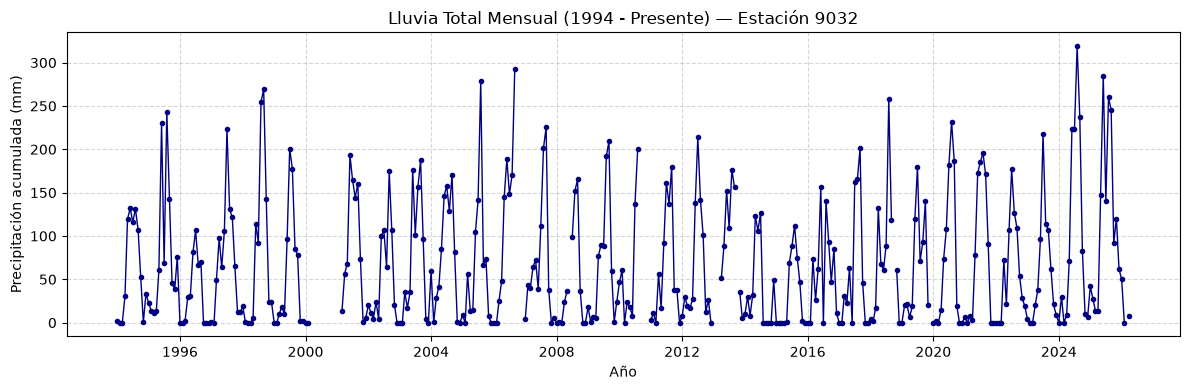

In [24]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['LLUVIA TOTAL MENSUAL'],
    color='navy',
    marker='.',
    linewidth=1,
)
plt.title(f'Lluvia Total Mensual (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Precipitación acumulada (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

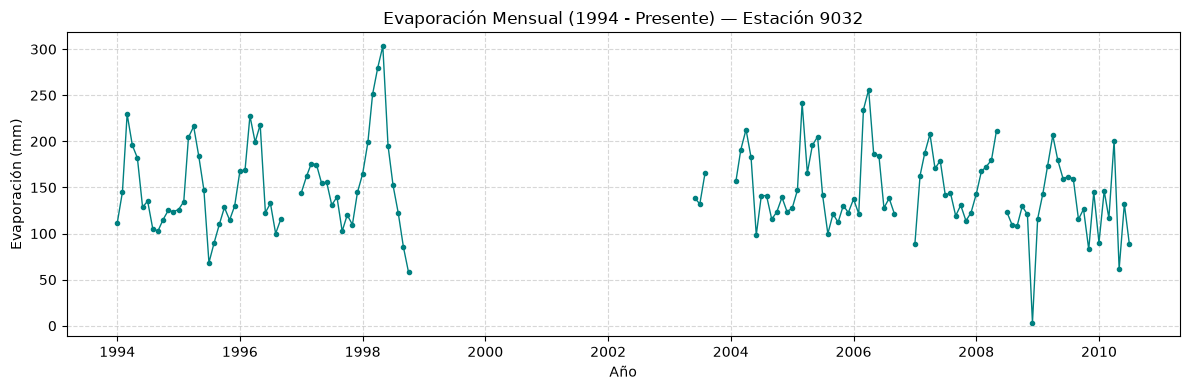

In [25]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['EVAPORACIÓN MENSUAL'],
    color='teal',
    marker='.',
    linewidth=1,
)
plt.title(f'Evaporación Mensual (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Evaporación (mm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

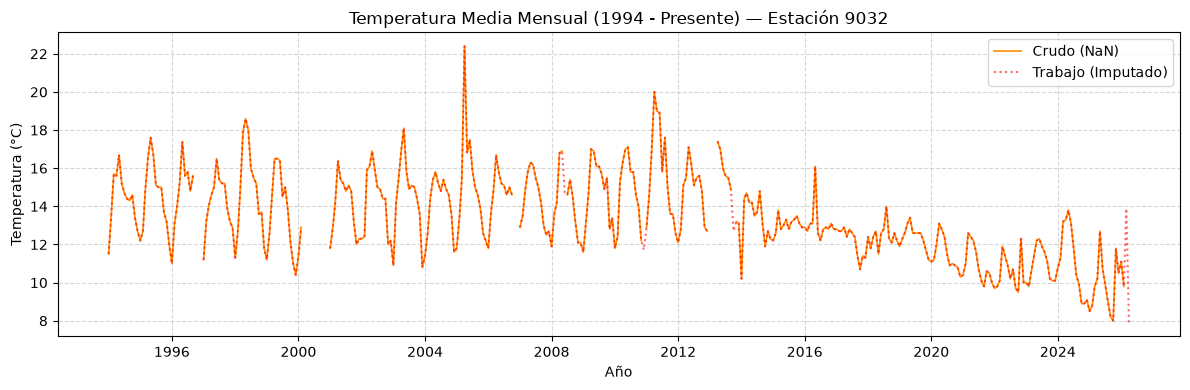

In [26]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['TEMPERATURA MEDIA MENSUAL'],
    color='darkorange',
    linewidth=1.2,
    label='Crudo (NaN)',
)
plt.plot(
    df_work.index,
    df_work['TEMPERATURA MEDIA MENSUAL'],
    color='red',
    linestyle=':',
    alpha=0.6,
    label='Trabajo (Imputado)',
)
plt.title(f'Temperatura Media Mensual (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

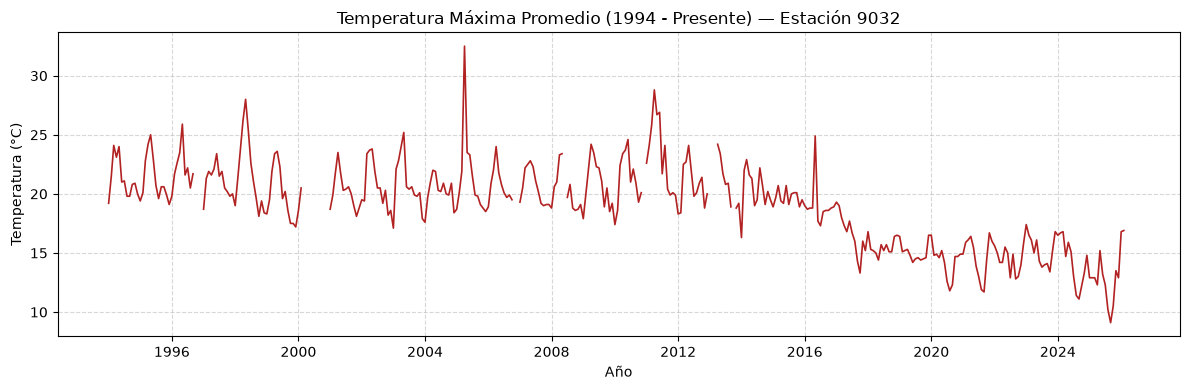

In [27]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['TEMPERATURA MÁXIMA PROMEDIO'],
    color='firebrick',
    linewidth=1.2,
)
plt.title(f'Temperatura Máxima Promedio (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Temperatura (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

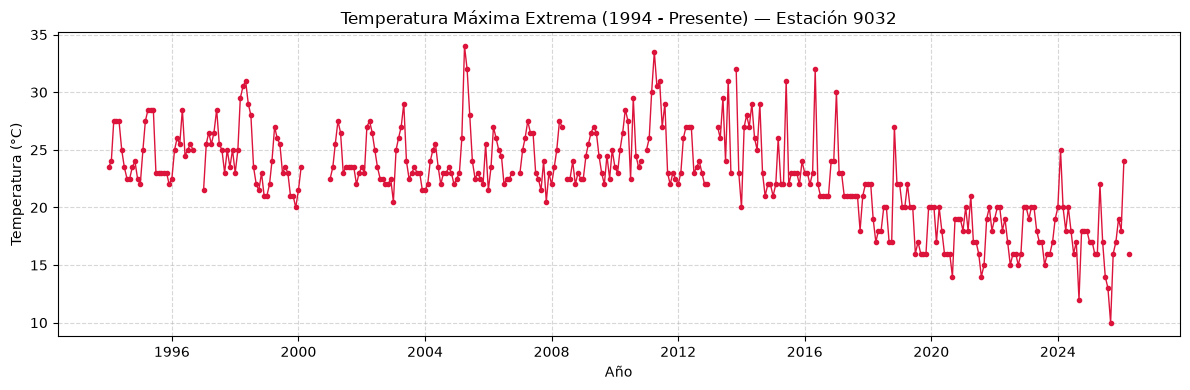

In [28]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['TEMPERATURA MÁXIMA EXTREMA'],
    color='crimson',
    marker='o',
    markersize=3,
    linewidth=1,
)
plt.title(f'Temperatura Máxima Extrema (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Temperatura (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

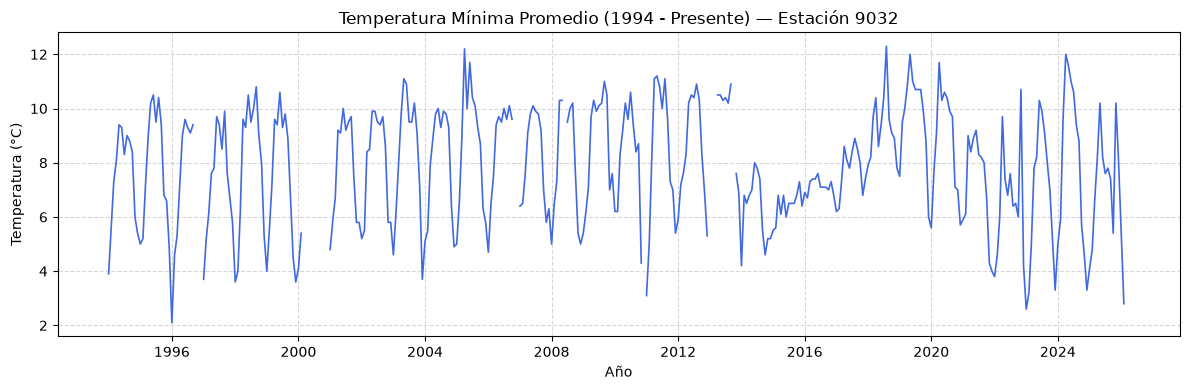

In [29]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['TEMPERATURA MÍNIMA PROMEDIO'],
    color='royalblue',
    linewidth=1.2,
)
plt.title(f'Temperatura Mínima Promedio (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Temperatura (°C)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

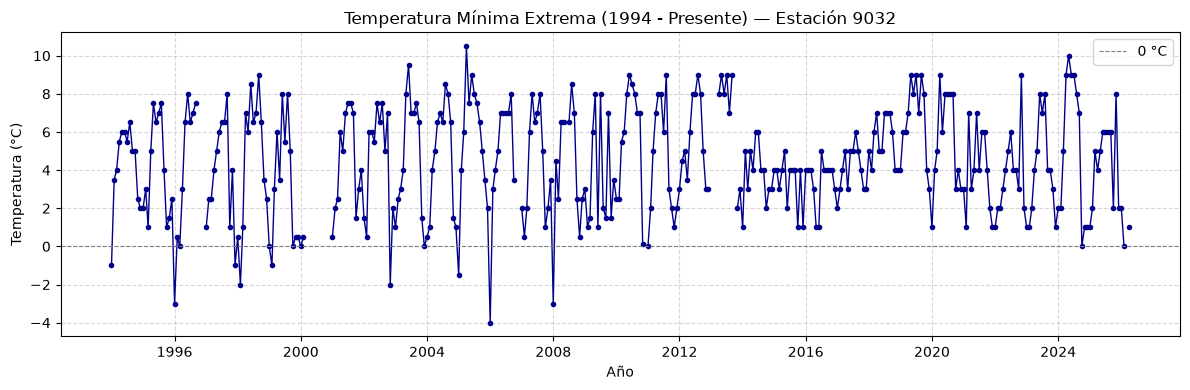

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(
    df_raw.index,
    df_raw['TEMPERATURA MÍNIMA EXTREMA'],
    color='darkblue',
    marker='o',
    markersize=3,
    linewidth=1,
)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, label='0 °C')
plt.title(f'Temperatura Mínima Extrema (1994 - Presente) — Estación {metadata["estacion"]}')
plt.xlabel('Año')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

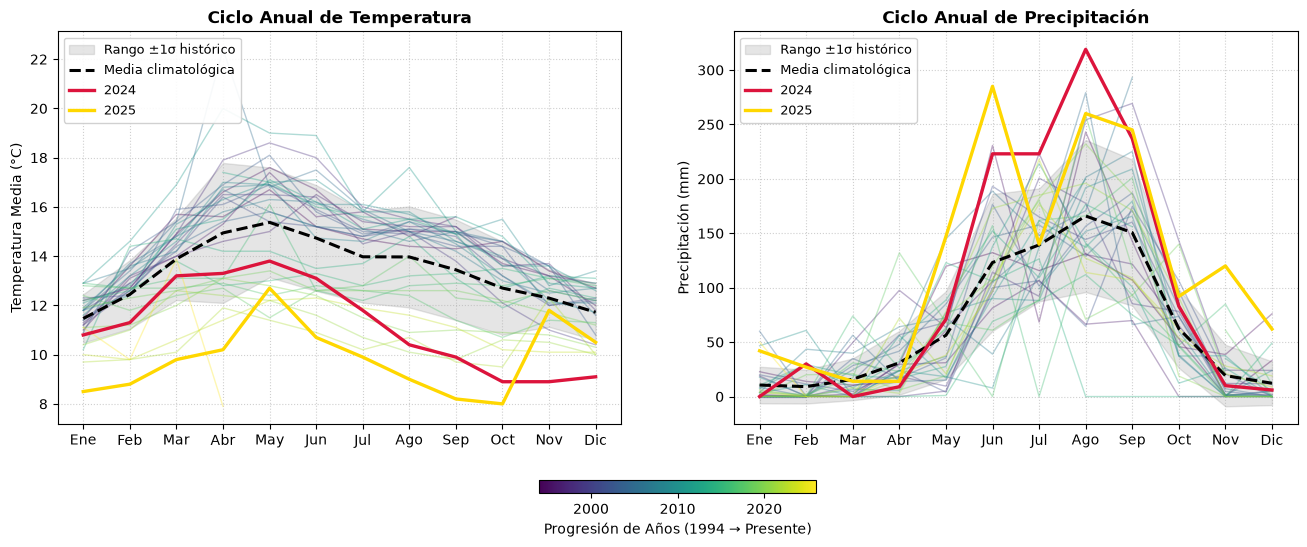

In [31]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Preparar tabla pivote (Meses en filas 1-12, Años en columnas)
df_plot = df_work.copy()
df_plot['AÑO'] = df_plot.index.year
df_plot['MES'] = df_plot.index.month

meses_labels = [
    'Ene',
    'Feb',
    'Mar',
    'Abr',
    'May',
    'Jun',
    'Jul',
    'Ago',
    'Sep',
    'Oct',
    'Nov',
    'Dic',
]
x_axis = np.arange(1, 13)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

variables = [
    (
        'TEMPERATURA MEDIA MENSUAL',
        'Temperatura Media (°C)',
        axes[0],
        'Ciclo Anual de Temperatura',
    ),
    (
        'LLUVIA TOTAL MENSUAL',
        'Precipitación (mm)',
        axes[1],
        'Ciclo Anual de Precipitación',
    ),
]

anios = sorted(df_plot['AÑO'].unique())
norm = plt.Normalize(vmin=min(anios), vmax=max(anios))
cmap = cm.viridis

for col_name, y_label, ax, title in variables:
  pivot = df_plot.pivot(index='MES', columns='AÑO', values=col_name).reindex(
      x_axis
  )

  # 1. Banda climatológica: Media +/- 1 Desviación Estándar
  media_clim = pivot.mean(axis=1)
  std_clim = pivot.std(axis=1)
  ax.fill_between(
      x_axis,
      media_clim - std_clim,
      media_clim + std_clim,
      color='gray',
      alpha=0.2,
      label='Rango ±1σ histórico',
  )
  ax.plot(
      x_axis,
      media_clim,
      color='black',
      linewidth=2.2,
      linestyle='--',
      label='Media climatológica',
      zorder=4,
  )

  # 2. Curvas de cada año con gradiente de color
  for anio in anios:
    if anio in [2024, 2025]:
      continue  # Se grafican al final para destacarlos
    ax.plot(
        x_axis,
        pivot[anio],
        color=cmap(norm(anio)),
        alpha=0.35,
        linewidth=1.0,
        zorder=2,
    )

  # 3. Resaltar años recientes anómalos
  if 2024 in pivot.columns:
    ax.plot(
        x_axis,
        pivot[2024],
        color='crimson',
        linewidth=2.4,
        label='2024',
        zorder=5,
    )
  if 2025 in pivot.columns:
    ax.plot(
        x_axis,
        pivot[2025],
        color='gold',
        linewidth=2.4,
        label='2025',
        zorder=5,
    )

  ax.set_title(title, fontsize=12, fontweight='bold')
  ax.set_ylabel(y_label)
  ax.set_xticks(x_axis)
  ax.set_xticklabels(meses_labels)
  ax.grid(True, linestyle=':', alpha=0.6)
  ax.legend(loc='upper left', framealpha=0.9, fontsize=9)

# Barra de color indicando la progresión de los años
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes, orientation='horizontal', fraction=0.03, pad=0.12
)
cbar.set_label('Progresión de Años (1994 → Presente)', fontsize=10)

plt.show()

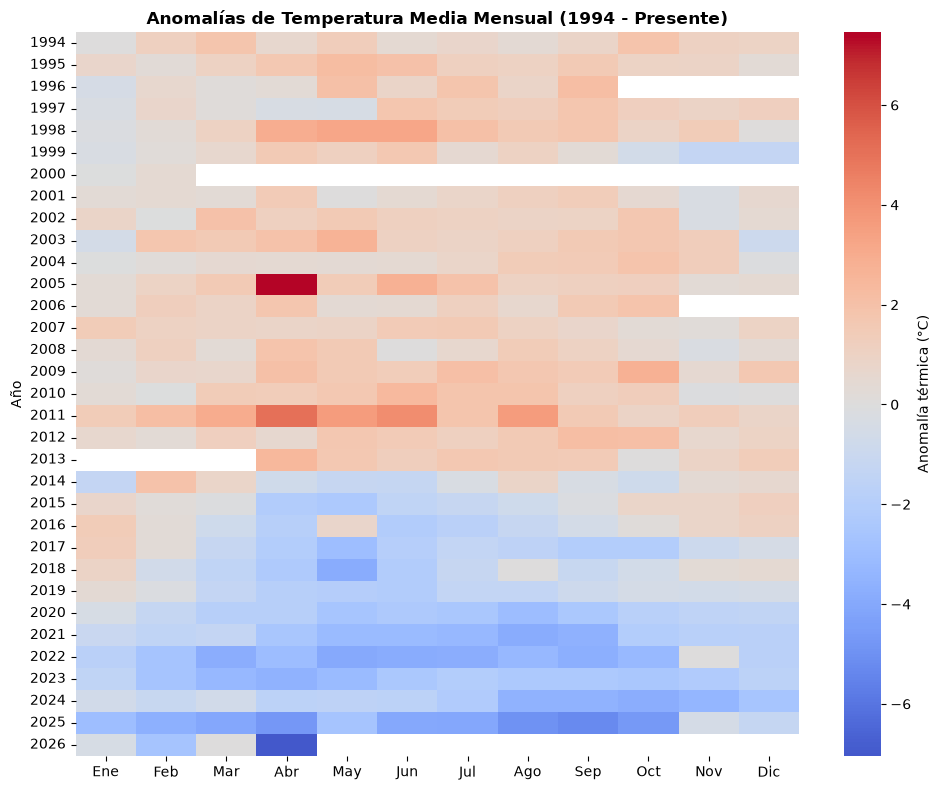

In [32]:
import seaborn as sns

plt.figure(figsize=(10, 8))
piv_temp = df_work.pivot_table(
    index=df_work.index.year,
    columns=df_work.index.month,
    values='TEMPERATURA MEDIA MENSUAL',
)
piv_temp.columns = meses_labels

# Restar la media histórica de cada mes para ver anomalías
anomalias_temp = piv_temp - piv_temp.mean(axis=0)

sns.heatmap(
    anomalias_temp,
    cmap='coolwarm',
    center=0,
    cbar_kws={'label': 'Anomalía térmica (°C)'},
)
plt.title(
    'Anomalías de Temperatura Media Mensual (1994 - Presente)',
    fontweight='bold',
)
plt.ylabel('Año')
plt.tight_layout()
plt.show()